In [1]:
!wget http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
!tar -xzvf ta-lib-0.4.0-src.tar.gz
%cd ta-lib
!./configure --prefix=/usr
!make
!make install

# Now install the Python wrapper
!pip install ta-lib

--2025-12-14 18:24:43--  http://prdownloads.sourceforge.net/ta-lib/ta-lib-0.4.0-src.tar.gz
Resolving prdownloads.sourceforge.net (prdownloads.sourceforge.net)... 104.18.12.149, 104.18.13.149, 2606:4700::6812:c95, ...
Connecting to prdownloads.sourceforge.net (prdownloads.sourceforge.net)|104.18.12.149|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: http://downloads.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz [following]
--2025-12-14 18:24:43--  http://downloads.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz
Resolving downloads.sourceforge.net (downloads.sourceforge.net)... 104.18.12.149, 104.18.13.149, 2606:4700::6812:c95, ...
Reusing existing connection to prdownloads.sourceforge.net:80.
HTTP request sent, awaiting response... 302 Found
Location: http://psychz.dl.sourceforge.net/project/ta-lib/ta-lib/0.4.0/ta-lib-0.4.0-src.tar.gz?viasf=1 [following]
--2025-12-14 18:24:43--  http://psychz.dl.sourcefo


# ANÁLISE FINANCEIRA COM yfinance
### Período: 2000-2025 | Dados Técnicos e Fundamentalistas


# 1. IMPORTAÇÃO DE BIBLIOTECAS

In [2]:
import os
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# Análise técnica
import talib

# Estatística
from scipy import stats
from scipy.stats import norm, kurtosis, skew

# Configurações
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.precision', 4)


# 2. DESCRIÇÃO DOS DATASETS


In [3]:
print("="*100)
print("DESCRIÇÃO DOS DATASETS - FONTE: Yahoo Finance (yfinance)")
print("="*100)

datasets_descricao = {
    "Dataset 1 - Dados Técnicos/Históricos": {
        "Origem": "Yahoo Finance API (yfinance)",
        "Formato": "Estruturado (DataFrame com MultiIndex)",
        "Estrutura": "OHLCV (Open, High, Low, Close, Volume) diário",
        "Volume Estimado": f"~25 anos × ~20 ativos × 252 dias/ano ≈ 126,000 registros",
        "Frequência": "Diária (mercado aberto)",
        "Veracidade": "Alta - dados oficiais de mercado",
        "Colunas Principais": ['Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close']
    },
    "Dataset 2 - Dados Fundamentalistas": {
        "Origem": "Yahoo Finance Info API",
        "Formato": "Semi-estruturado (JSON/Dicionário)",
        "Estrutura": "Informações empresariais e financeiras",
        "Volume Estimado": f"~20 empresas × 50 campos ≈ 1,000 pontos de dados",
        "Frequência": "Trimestral/Anual (resultados)",
        "Veracidade": "Moderada-Alta - dados reportados pelas empresas",
        "Campos Principais": ['marketCap', 'trailingPE', 'forwardPE', 'priceToBook',
                             'dividendYield', 'beta', 'returnOnEquity', 'debtToEquity']
    }
}

for dataset, info in datasets_descricao.items():
    print(f"\n{dataset}:")
    for key, value in info.items():
        print(f"  • {key}: {value}")

DESCRIÇÃO DOS DATASETS - FONTE: Yahoo Finance (yfinance)

Dataset 1 - Dados Técnicos/Históricos:
  • Origem: Yahoo Finance API (yfinance)
  • Formato: Estruturado (DataFrame com MultiIndex)
  • Estrutura: OHLCV (Open, High, Low, Close, Volume) diário
  • Volume Estimado: ~25 anos × ~20 ativos × 252 dias/ano ≈ 126,000 registros
  • Frequência: Diária (mercado aberto)
  • Veracidade: Alta - dados oficiais de mercado
  • Colunas Principais: ['Open', 'High', 'Low', 'Close', 'Volume', 'Adj Close']

Dataset 2 - Dados Fundamentalistas:
  • Origem: Yahoo Finance Info API
  • Formato: Semi-estruturado (JSON/Dicionário)
  • Estrutura: Informações empresariais e financeiras
  • Volume Estimado: ~20 empresas × 50 campos ≈ 1,000 pontos de dados
  • Frequência: Trimestral/Anual (resultados)
  • Veracidade: Moderada-Alta - dados reportados pelas empresas
  • Campos Principais: ['marketCap', 'trailingPE', 'forwardPE', 'priceToBook', 'dividendYield', 'beta', 'returnOnEquity', 'debtToEquity']


# 3. CONFIGURAÇÃO DO PROJETO


In [4]:
DATA_INICIO = "2000-01-01"
DATA_FIM = "2025-11-30"

# Ativos selecionados
TICKERS = {
    'Tecnologia': ['AAPL', 'MSFT', 'GOOGL', 'NVDA', 'META'],
    'Financeiro': ['JPM', 'BAC', 'GS', 'WFC', 'C'],
    'Energia': ['XOM', 'CVX', 'COP'],
    'Saúde': ['JNJ', 'UNH', 'PFE'],
    'Consumo': ['WMT', 'AMZN', 'HD'],
    'Índices': ['^GSPC', '^DJI', '^IXIC']
}

TODOS_TICKERS = [ticker for lista in TICKERS.values() for ticker in lista]
ACOES_APENAS = [t for t in TODOS_TICKERS if not t.startswith('^')]

print(f"\n{'='*80}")
print("CONFIGURAÇÃO DA ANÁLISE")
print(f"{'='*80}")
print(f"• Período: {DATA_INICIO} a {DATA_FIM}")
print(f"• Total de ativos: {len(TODOS_TICKERS)}")
print(f"• Categorias: {list(TICKERS.keys())}")


CONFIGURAÇÃO DA ANÁLISE
• Período: 2000-01-01 a 2025-11-30
• Total de ativos: 22
• Categorias: ['Tecnologia', 'Financeiro', 'Energia', 'Saúde', 'Consumo', 'Índices']


# 4. EXTRAÇÃO DE DADOS

In [5]:
print(f"\n{'='*80}")
print("ETAPA 1: EXTRAÇÃO DE DADOS")
print(f"{'='*80}")

# 4.1 Extração de dados técnicos
print("\n Extraindo dados técnicos (preços históricos)...")
dados_tecnicos = {}

for ticker in TODOS_TICKERS:
    try:
        print(f"  • {ticker}: ", end="")
        dados = yf.download(ticker, start=DATA_INICIO, end=DATA_FIM, progress=False)
        if not dados.empty:
            dados_tecnicos[ticker] = dados
            print(f"✓ {len(dados)} registros")
        else:
            print("✗ Sem dados")
    except Exception as e:
        print(f"✗ Erro: {str(e)[:50]}")

print(f"\n Dados técnicos extraídos: {len(dados_tecnicos)}/{len(TODOS_TICKERS)} ativos")

# 4.2 Extração de dados fundamentalistas
print("\n Extraindo dados fundamentalistas...")
dados_fundamentalistas = {}

for ticker in ACOES_APENAS:
    try:
        empresa = yf.Ticker(ticker)
        info = empresa.info

        dados_fund = {
            'Ticker': ticker,
            'Nome': info.get('longName', 'N/A'),
            'Setor': info.get('sector', 'N/A'),
            'MarketCap': info.get('marketCap', np.nan),
            'PE': info.get('trailingPE', np.nan),
            'Forward_PE': info.get('forwardPE', np.nan),
            'PB': info.get('priceToBook', np.nan),
            'PS': info.get('priceToSalesTrailing12Months', np.nan),
            'Dividend_Yield': info.get('dividendYield', np.nan),
            'Beta': info.get('beta', np.nan),
            'ROE': info.get('returnOnEquity', np.nan),
            'ROA': info.get('returnOnAssets', np.nan),
            'Profit_Margin': info.get('profitMargins', np.nan),
            'Current_Ratio': info.get('currentRatio', np.nan),
            'Debt_to_Equity': info.get('debtToEquity', np.nan),
            'Revenue_Growth': info.get('revenueGrowth', np.nan),
            'Gross_Margin': info.get('grossMargins', np.nan),
            'Operating_Margin': info.get('operatingMargins', np.nan),
            'Free_Cashflow': info.get('freeCashflow', np.nan),
            '52W_High': info.get('fiftyTwoWeekHigh', np.nan),
            '52W_Low': info.get('fiftyTwoWeekLow', np.nan)
        }

        dados_fundamentalistas[ticker] = dados_fund
        print(f"  • {ticker}: ✓ {len([v for v in dados_fund.values() if v not in [np.nan, 'N/A']])} campos válidos")
    except Exception as e:
        print(f"  • {ticker}: ✗ {str(e)[:50]}")

print(f"\n Dados fundamentalistas extraídos: {len(dados_fundamentalistas)} empresas")


ETAPA 1: EXTRAÇÃO DE DADOS

 Extraindo dados técnicos (preços históricos)...
  • AAPL: ✓ 6517 registros
  • MSFT: ✓ 6517 registros
  • GOOGL: ✓ 5355 registros
  • NVDA: ✓ 6517 registros
  • META: ✓ 3403 registros
  • JPM: ✓ 6517 registros
  • BAC: ✓ 6517 registros
  • GS: ✓ 6517 registros
  • WFC: ✓ 6517 registros
  • C: ✓ 6517 registros
  • XOM: ✓ 6517 registros
  • CVX: ✓ 6517 registros
  • COP: ✓ 6517 registros
  • JNJ: ✓ 6517 registros
  • UNH: ✓ 6517 registros
  • PFE: ✓ 6517 registros
  • WMT: ✓ 6517 registros
  • AMZN: ✓ 6517 registros
  • HD: ✓ 6517 registros
  • ^GSPC: ✓ 6517 registros
  • ^DJI: ✓ 6517 registros
  • ^IXIC: ✓ 6517 registros

 Dados técnicos extraídos: 22/22 ativos

 Extraindo dados fundamentalistas...
  • AAPL: ✓ 21 campos válidos
  • MSFT: ✓ 21 campos válidos
  • GOOGL: ✓ 21 campos válidos
  • NVDA: ✓ 21 campos válidos
  • META: ✓ 21 campos válidos
  • JPM: ✓ 18 campos válidos
  • BAC: ✓ 18 campos válidos
  • GS: ✓ 20 campos válidos
  • WFC: ✓ 18 campos válid

# 5. PROCESSAMENTO E CONSOLIDAÇÃO

In [6]:
print(f"\n{'='*80}")
print("ETAPA 2: PROCESSAMENTO E CONSOLIDAÇÃO")
print(f"{'='*80}")

# 5.1 Consolidar dados técnicos
def consolidar_dados_tecnicos(dados_dict):
    """Consolida dados técnicos em DataFrames separados"""
    precos_fechamento = pd.DataFrame()
    volumes = pd.DataFrame()

    for ticker, dados in dados_dict.items():
        if 'Close' in dados.columns:
            # Lidar com MultiIndex se necessário
            if isinstance(dados['Close'], pd.DataFrame):
                close_series = dados['Close'].iloc[:, 0] if len(dados['Close'].columns) > 0 else pd.Series()
            else:
                close_series = dados['Close']

            if not close_series.empty:
                precos_fechamento[ticker] = close_series

        if 'Volume' in dados.columns:
            if isinstance(dados['Volume'], pd.DataFrame):
                volume_series = dados['Volume'].iloc[:, 0] if len(dados['Volume'].columns) > 0 else pd.Series()
            else:
                volume_series = dados['Volume']

            if not volume_series.empty:
                volumes[ticker] = volume_series

    # Limpeza de dados
    precos_fechamento = precos_fechamento.fillna(method='ffill').fillna(method='bfill')
    volumes = volumes.fillna(0)

    return precos_fechamento, volumes

precos_fechamento, volumes = consolidar_dados_tecnicos(dados_tecnicos)
print(f" Dados técnicos consolidados:")
print(f"  • Preços de fechamento: {precos_fechamento.shape[0]} dias × {precos_fechamento.shape[1]} ativos")
print(f"  • Volumes: {volumes.shape[0]} dias × {volumes.shape[1]} ativos")

# 5.2 Consolidar dados fundamentalistas
df_fundamentalistas = pd.DataFrame(dados_fundamentalistas).T
print(f"\n Dados fundamentalistas consolidados: {df_fundamentalistas.shape}")

# 5.3 Calcular retornos
retornos_diarios = precos_fechamento.pct_change().dropna()
retornos_acumulados = ((1 + retornos_diarios).cumprod() - 1) * 100
print(f"\n Retornos calculados: {retornos_diarios.shape}")


ETAPA 2: PROCESSAMENTO E CONSOLIDAÇÃO
 Dados técnicos consolidados:
  • Preços de fechamento: 6517 dias × 22 ativos
  • Volumes: 6517 dias × 22 ativos

 Dados fundamentalistas consolidados: (19, 21)

 Retornos calculados: (6516, 22)


# 6. ANÁLISE EXPLORATÓRIA DESCRITIVA

In [7]:
print(f"\n{'='*80}")
print("ETAPA 3: ANÁLISE EXPLORATÓRIA DESCRITIVA")
print(f"{'='*80}")

# 6.1 Identificação de variáveis
print("\n VARIÁVEIS RELEVANTES:")
print("\nDADOS TÉCNICOS (Quantitativas Contínuas):")
print("  • Preço de fechamento (USD)")
print("  • Volume negociado")
print("  • Retorno diário (%)")
print("  • Volatilidade (desvio padrão dos retornos)")
print("  • Máximo drawdown")

print("\nDADOS FUNDAMENTALISTAS:")
print("  • Market Capitalization (USD) - Quantitativa Contínua")
print("  • P/E Ratio - Quantitativa Contínua")
print("  • Dividend Yield (%) - Quantitativa Contínua")
print("  • Beta - Quantitativa Contínua")
print("  • ROE (%) - Quantitativa Contínua")
print("  • Setor (Tecnologia, Financeiro, etc.) - Qualitativa Nominal")

# 6.2 Medidas de tendência central e dispersão
print(f"\n{'='*80}")
print("MEDIDAS DE TENDÊNCIA CENTRAL E DISPERSÃO")
print(f"{'='*80}")

# Para dados técnicos (preços)
if not precos_fechamento.empty:
    estatisticas_precos = pd.DataFrame({
        'Média (USD)': precos_fechamento.mean(),
        'Mediana (USD)': precos_fechamento.median(),
        'Desvio_Padrão (USD)': precos_fechamento.std(),
        'Variância': precos_fechamento.var(),
        'Coef_Variação (%)': (precos_fechamento.std() / precos_fechamento.mean() * 100),
        'Mínimo (USD)': precos_fechamento.min(),
        'Máximo (USD)': precos_fechamento.max(),
        'Amplitude (USD)': precos_fechamento.max() - precos_fechamento.min()
    })

    print("\n ESTATÍSTICAS DOS PREÇOS DE FECHAMENTO:")
    print(estatisticas_precos.round(2).head())

# Para retornos
if not retornos_diarios.empty:
    estatisticas_retornos = pd.DataFrame({
        'Média_Diária (%)': retornos_diarios.mean() * 100,
        'Mediana_Diária (%)': retornos_diarios.median() * 100,
        'Desvio_Padrão_Diário (%)': retornos_diarios.std() * 100,
        'Variância_Diária': retornos_diarios.var(),
        'Skewness': retornos_diarios.apply(skew),
        'Kurtosis': retornos_diarios.apply(kurtosis),
        'VaR_95% (%)': retornos_diarios.apply(lambda x: np.percentile(x, 5)) * 100,
        'VaR_99% (%)': retornos_diarios.apply(lambda x: np.percentile(x, 1)) * 100
    })

    print("\n ESTATÍSTICAS DOS RETORNOS DIÁRIOS:")
    print(estatisticas_retornos.round(4).head())

# Para dados fundamentalistas
if not df_fundamentalistas.empty:
    colunas_numericas = ['MarketCap', 'PE', 'PB', 'Dividend_Yield', 'Beta',
                        'ROE', 'Profit_Margin', 'Current_Ratio']

    colunas_disponiveis = [c for c in colunas_numericas if c in df_fundamentalistas.columns]

    if colunas_disponiveis:
        for col in colunas_disponiveis:
            try:
                df_fundamentalistas[col] = pd.to_numeric(df_fundamentalistas[col], errors='coerce')
            except:
                pass

        estatisticas_fund = pd.DataFrame({
            'Média': df_fundamentalistas[colunas_disponiveis].mean(),
            'Mediana': df_fundamentalistas[colunas_disponiveis].median(),
            'Desvio_Padrão': df_fundamentalistas[colunas_disponiveis].std(),
            'Mínimo': df_fundamentalistas[colunas_disponiveis].min(),
            'Máximo': df_fundamentalistas[colunas_disponiveis].max()
        })

        print("\n ESTATÍSTICAS DOS DADOS FUNDAMENTALISTAS:")
        print(estatisticas_fund.round(4))



ETAPA 3: ANÁLISE EXPLORATÓRIA DESCRITIVA

 VARIÁVEIS RELEVANTES:

DADOS TÉCNICOS (Quantitativas Contínuas):
  • Preço de fechamento (USD)
  • Volume negociado
  • Retorno diário (%)
  • Volatilidade (desvio padrão dos retornos)
  • Máximo drawdown

DADOS FUNDAMENTALISTAS:
  • Market Capitalization (USD) - Quantitativa Contínua
  • P/E Ratio - Quantitativa Contínua
  • Dividend Yield (%) - Quantitativa Contínua
  • Beta - Quantitativa Contínua
  • ROE (%) - Quantitativa Contínua
  • Setor (Tecnologia, Financeiro, etc.) - Qualitativa Nominal

MEDIDAS DE TENDÊNCIA CENTRAL E DISPERSÃO

 ESTATÍSTICAS DOS PREÇOS DE FECHAMENTO:
       Média (USD)  Mediana (USD)  Desvio_Padrão (USD)  Variância  \
AAPL         47.63          15.69                68.28    4661.87   
MSFT         97.95          25.52               129.00   16640.65   
GOOGL        44.88          18.23                53.74    2888.42   
NVDA         13.49           0.46                34.90    1217.81   
META        131.50       

# 7. MINERAÇÃO DE DADOS E FEATURE ENGINEERING

In [8]:
print(f"\n{'='*80}")
print("ETAPA 4: FEATURE ENGINEERING E MINERAÇÃO DE DADOS")
print(f"{'='*80}")

# 7.1 Feature Engineering para dados técnicos
print("\n FEATURE ENGINEERING - DADOS TÉCNICOS:")

if not precos_fechamento.empty:
    # Indicadores técnicos usando TA-Lib
    for ticker in precos_fechamento.columns[:5]:  # Apenas primeiros 5
        try:
            preco_array = precos_fechamento[ticker].values

            # Calcular indicadores
            rsi = talib.RSI(preco_array, timeperiod=14)
            macd, macd_signal, macd_hist = talib.MACD(preco_array)
            upper, middle, lower = talib.BBANDS(preco_array, timeperiod=20)

            # Armazenar os primeiros valores
            if ticker == precos_fechamento.columns[0]:
                print(f"  • {ticker}: RSI atual = {rsi[-1]:.2f}, MACD = {macd[-1]:.4f}")

        except Exception as e:
            print(f"  • {ticker}: Erro ao calcular indicadores - {str(e)[:50]}")

# 7.2 Engenharia de atributos
def calcular_indicadores_avancados(df_precos):
    """Calcula indicadores técnicos avançados"""
    indicadores = pd.DataFrame(index=df_precos.index)

    for ticker in df_precos.columns:
        preco = df_precos[ticker].dropna()

        if len(preco) > 50:  # Precisa de dados suficientess
            # Retornos
            retornos = preco.pct_change()

            # Volatilidade rolante
            volatilidade_21d = retornos.rolling(window=21).std() * np.sqrt(252) * 100

            # Médias móveis
            sma_50 = preco.rolling(window=50).mean()
            sma_200 = preco.rolling(window=200).mean()

            # RSI (implementação manual)
            delta = preco.diff()
            gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
            loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
            rs = gain / loss
            rsi = 100 - (100 / (1 + rs))

            # Armazenar no DataFrame de indicadores
            indicadores[f'{ticker}_SMA50'] = sma_50
            indicadores[f'{ticker}_SMA200'] = sma_200
            indicadores[f'{ticker}_Volatilidade'] = volatilidade_21d
            indicadores[f'{ticker}_RSI'] = rsi

    return indicadores

print("\n Calculando indicadores técnicos...")
indicadores_tecnicos = calcular_indicadores_avancados(precos_fechamento.iloc[:, :5])  # Primeiros 5 ativos
print(f" Indicadores calculados: {indicadores_tecnicos.shape}")

# 7.3 Feature Engineering para dados fundamentalistas
print("\n FEATURE ENGINEERING - DADOS FUNDAMENTALISTAS:")

if not df_fundamentalistas.empty:
    # Criar features derivadas
    features_fund = df_fundamentalistas.copy()

    # Features baseadas em múltiplos
    if 'PE' in features_fund.columns and 'Dividend_Yield' in features_fund.columns:
        features_fund['PE_Dividend_Ratio'] = features_fund['PE'] / (features_fund['Dividend_Yield'] * 100 + 0.001)
        print("  • Criada feature: PE_Dividend_Ratio")

    if 'MarketCap' in features_fund.columns:
        features_fund['MarketCap_Category'] = pd.qcut(features_fund['MarketCap'],
                                                      q=4,
                                                      labels=['Micro', 'Small', 'Medium', 'Large'])
        print("  • Criada feature: MarketCap_Category")

    if 'ROE' in features_fund.columns and 'PB' in features_fund.columns:
        features_fund['ROE_PB_Score'] = features_fund['ROE'] / (features_fund['PB'] + 0.001)
        print("  • Criada feature: ROE_PB_Score")

    # Normalização de features
    colunas_para_normalizar = ['PE', 'PB', 'Beta', 'ROE', 'Profit_Margin']
    colunas_existentes = [c for c in colunas_para_normalizar if c in features_fund.columns]

    for col in colunas_existentes:
        try:
            features_fund[f'{col}_ZScore'] = (features_fund[col] - features_fund[col].mean()) / features_fund[col].std()
            print(f"  • Normalizada feature: {col}_ZScore")
        except:
            pass



ETAPA 4: FEATURE ENGINEERING E MINERAÇÃO DE DADOS

 FEATURE ENGINEERING - DADOS TÉCNICOS:
  • AAPL: RSI atual = 68.41, MACD = 4.2040

 Calculando indicadores técnicos...
 Indicadores calculados: (6517, 20)

 FEATURE ENGINEERING - DADOS FUNDAMENTALISTAS:
  • Criada feature: PE_Dividend_Ratio
  • Criada feature: MarketCap_Category
  • Criada feature: ROE_PB_Score
  • Normalizada feature: PE_ZScore
  • Normalizada feature: PB_ZScore
  • Normalizada feature: Beta_ZScore
  • Normalizada feature: ROE_ZScore
  • Normalizada feature: Profit_Margin_ZScore


# 8. VISUALIZAÇÕES


ETAPA 5: Graficoss

 Gerando Graficos...
 Gráfico 1: precos_normalizados.png
 Gráfico 2: retornos_acumulados.png
 Gráfico 3: distribuicao_retornos.png
 Gráfico 4: matriz_correlacao.png
 Gráfico 5: pe_vs_roe.png
 Gráfico 6 : risco_retorno.png


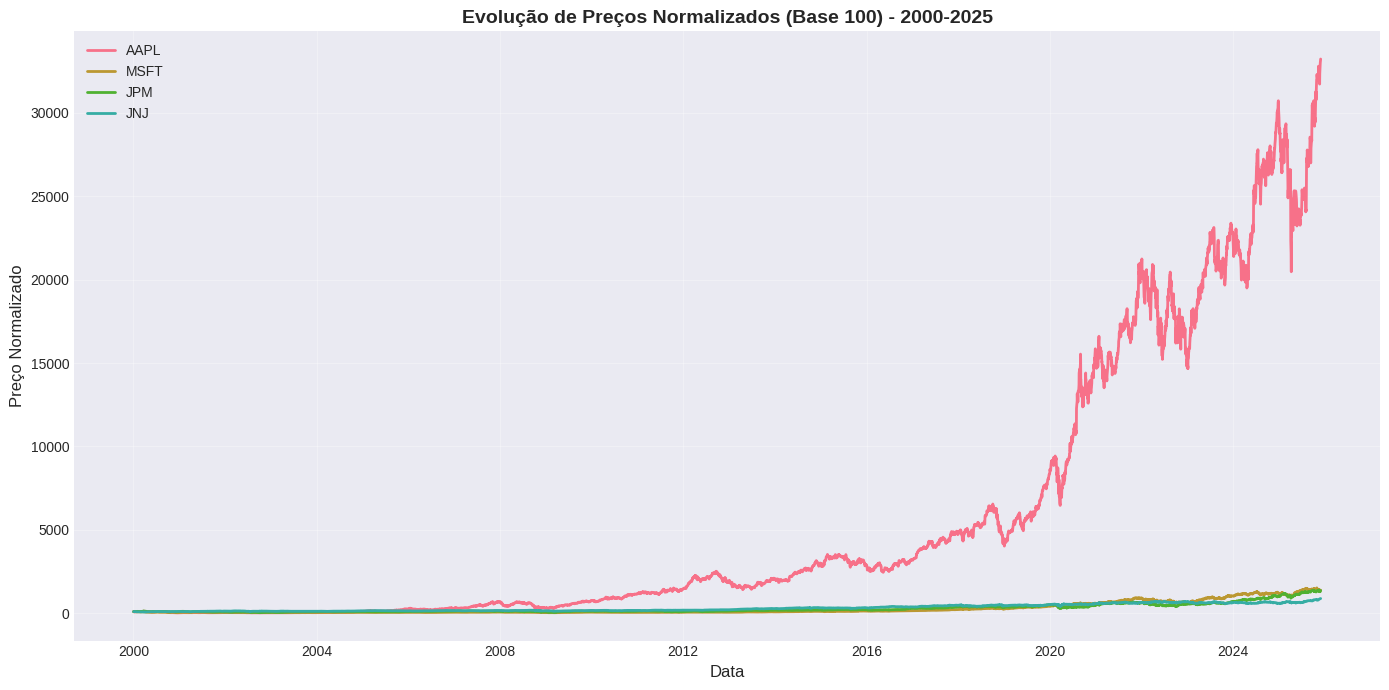

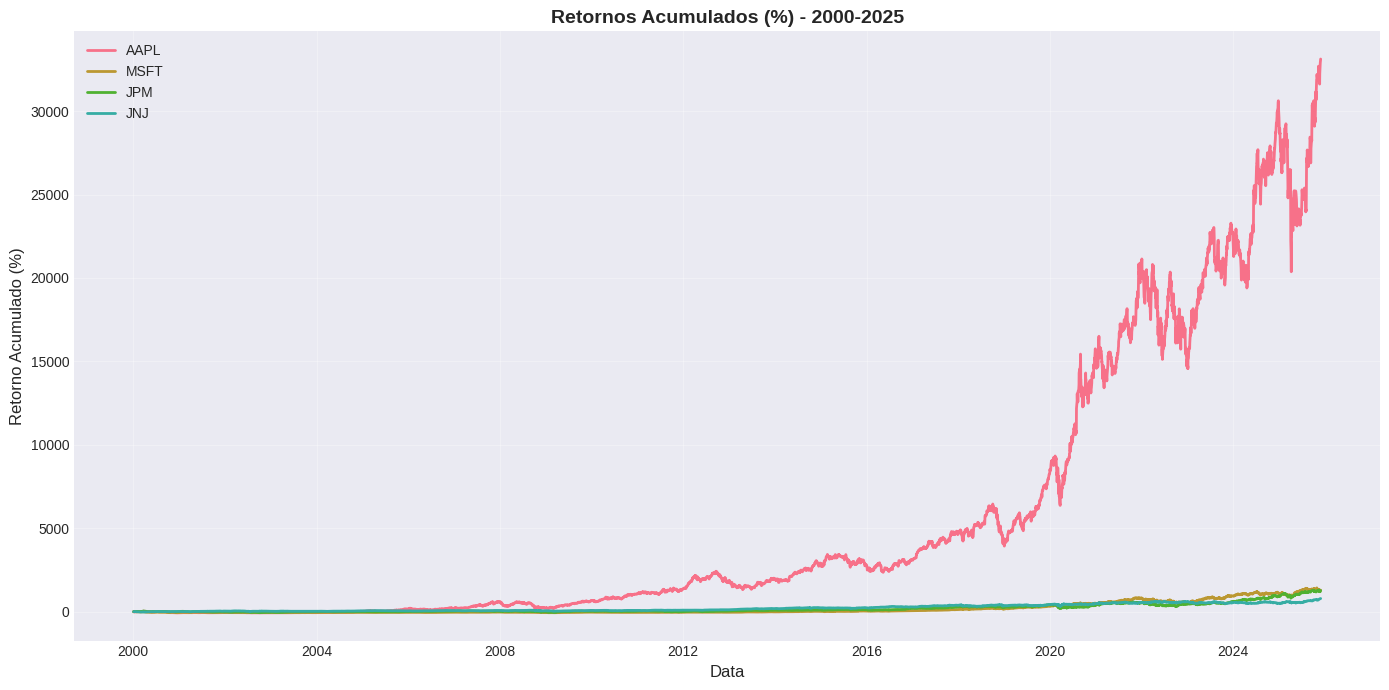

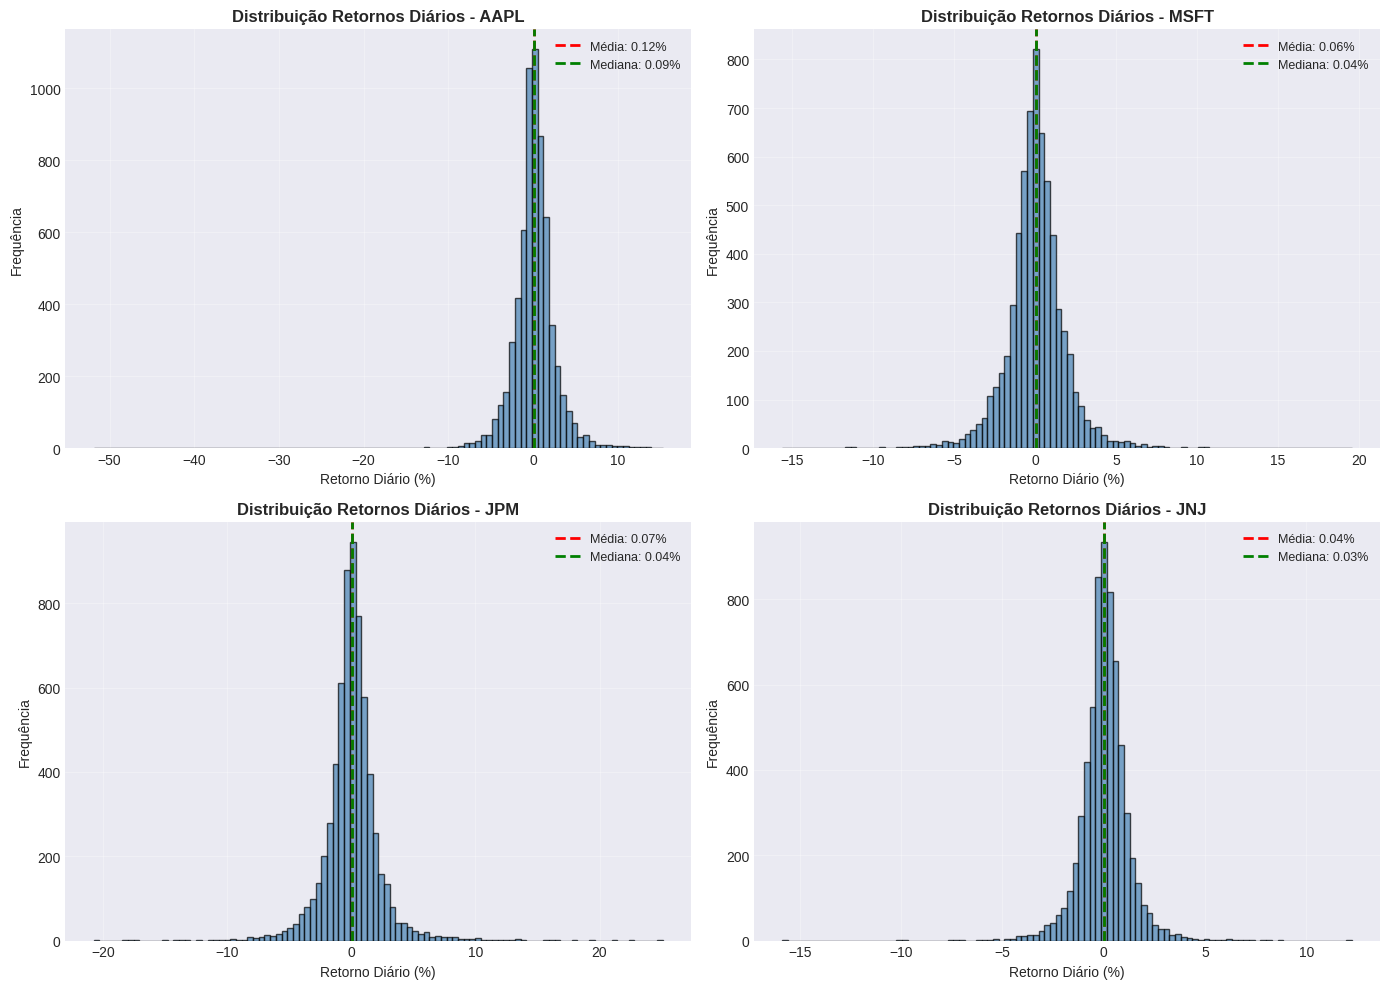

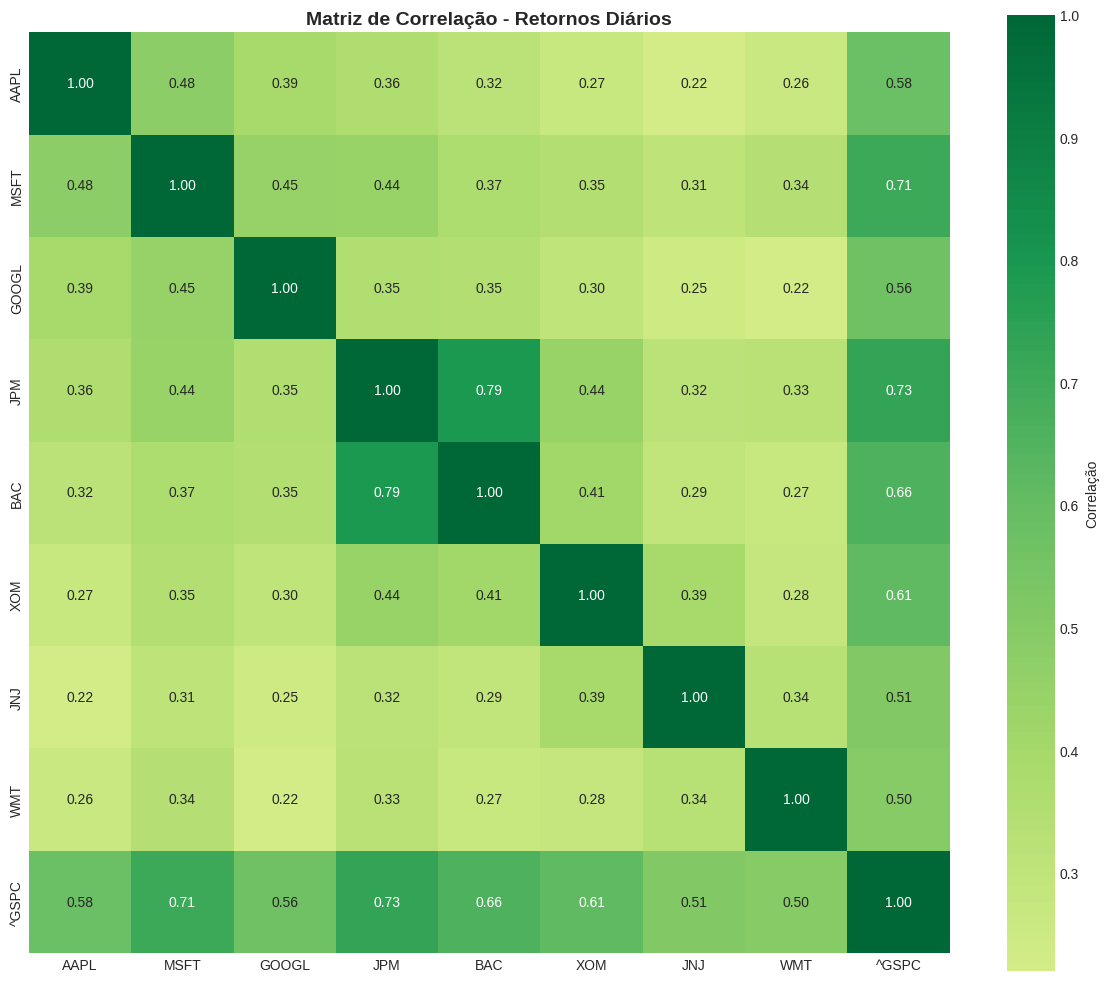

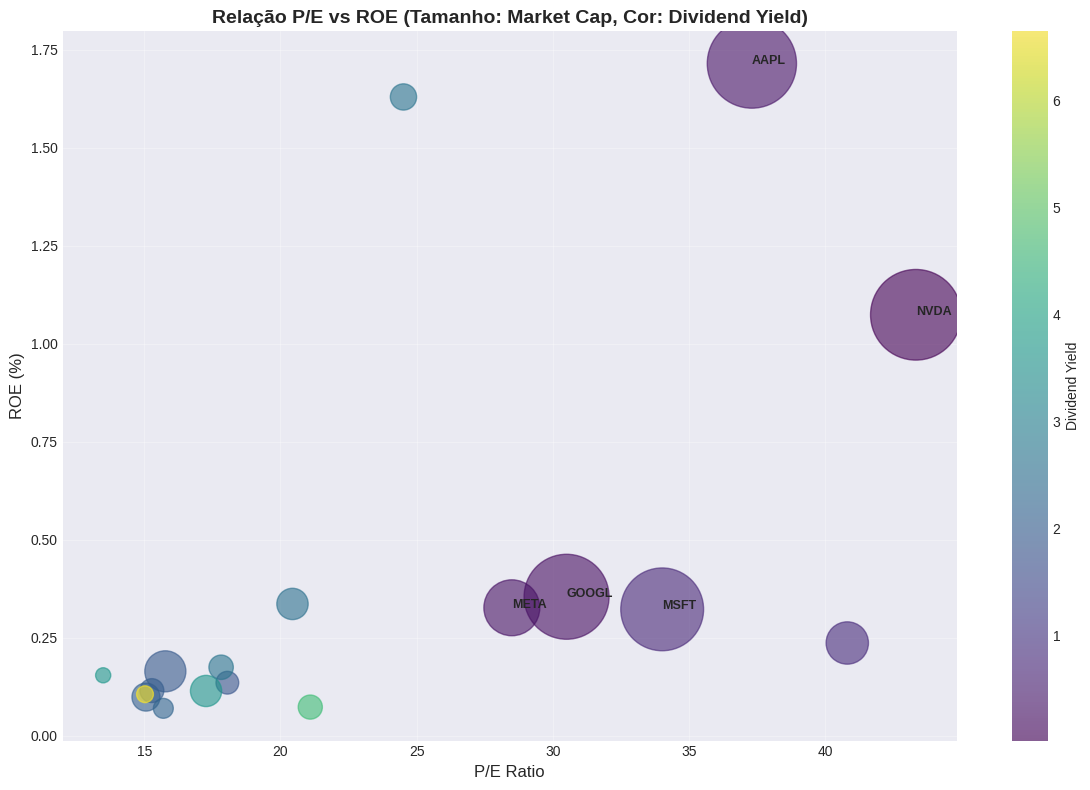

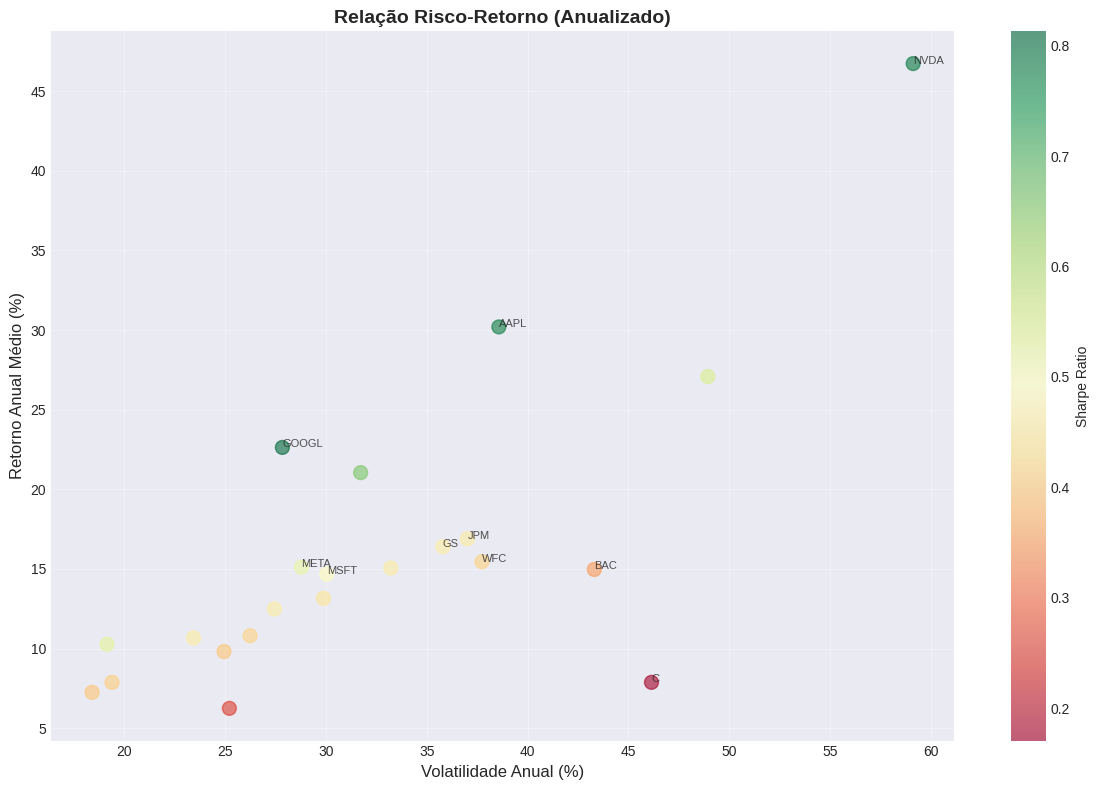

In [9]:
print(f"\n{'='*80}")
print("ETAPA 5: Graficoss")
print(f"{'='*80}")

# 8.1 Configurações de visualização
print("\n Gerando Graficos...")

# Gráfico 1: Evolução de preços normalizados
fig1, ax1 = plt.subplots(figsize=(14, 7))
ativos_plot = ['AAPL', 'MSFT', 'JPM', 'JNJ']  # Ativos representativos

for ticker in ativos_plot:
    if ticker in precos_fechamento.columns:
        normalizado = (precos_fechamento[ticker] / precos_fechamento[ticker].iloc[0] * 100)
        ax1.plot(normalizado.index, normalizado.values, label=ticker, linewidth=2)

ax1.set_title('Evolução de Preços Normalizados (Base 100) - 2000-2025',
              fontsize=14, fontweight='bold')
ax1.set_ylabel('Preço Normalizado', fontsize=12)
ax1.set_xlabel('Data', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('precos_normalizados.png', dpi=300, bbox_inches='tight')
print(" Gráfico 1: precos_normalizados.png")

# Gráfico 2: Retornos acumulados
fig2, ax2 = plt.subplots(figsize=(14, 7))

if not retornos_acumulados.empty:
    for ticker in ativos_plot:
        if ticker in retornos_acumulados.columns:
            ax2.plot(retornos_acumulados.index, retornos_acumulados[ticker],
                    label=ticker, linewidth=2)

ax2.set_title('Retornos Acumulados (%) - 2000-2025', fontsize=14, fontweight='bold')
ax2.set_ylabel('Retorno Acumulado (%)', fontsize=12)
ax2.set_xlabel('Data', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('retornos_acumulados.png', dpi=300, bbox_inches='tight')
print(" Gráfico 2: retornos_acumulados.png")

# Gráfico 3: Distribuição de retornos diários
fig3, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, ticker in enumerate(ativos_plot[:4]):
    if ticker in retornos_diarios.columns:
        ax = axes[i]
        retornos = retornos_diarios[ticker].dropna() * 100

        ax.hist(retornos, bins=100, alpha=0.7, color='steelblue', edgecolor='black')
        ax.axvline(x=retornos.mean(), color='red', linestyle='--', linewidth=2, label=f'Média: {retornos.mean():.2f}%')
        ax.axvline(x=retornos.median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {retornos.median():.2f}%')

        ax.set_title(f'Distribuição Retornos Diários - {ticker}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Retorno Diário (%)', fontsize=10)
        ax.set_ylabel('Frequência', fontsize=10)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distribuicao_retornos.png', dpi=300, bbox_inches='tight')
print(" Gráfico 3: distribuicao_retornos.png")

# Gráfico 4: Matriz de correlação
fig4, ax4 = plt.subplots(figsize=(12, 10))

if not retornos_diarios.empty:
    # Selecionar alguns ativos para matriz de correlação
    ativos_corr = ['AAPL', 'MSFT', 'GOOGL', 'JPM', 'BAC', 'XOM', 'JNJ', 'WMT', '^GSPC']
    ativos_disponiveis = [a for a in ativos_corr if a in retornos_diarios.columns]

    if len(ativos_disponiveis) > 3:
        corr_matrix = retornos_diarios[ativos_disponiveis].corr()

        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
                    center=0, square=True, ax=ax4, cbar_kws={'label': 'Correlação'})
        ax4.set_title('Matriz de Correlação - Retornos Diários', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig('matriz_correlacao.png', dpi=300, bbox_inches='tight')
        print(" Gráfico 4: matriz_correlacao.png")

# Gráfico 5: Análise fundamentalista
if not df_fundamentalistas.empty:
    # Preparar dados para visualização
    df_plot = df_fundamentalistas.copy()
    colunas_numericas = ['PE', 'PB', 'Dividend_Yield', 'Beta', 'ROE']

    for col in colunas_numericas:
        if col in df_plot.columns:
            try:
                df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')
            except:
                pass

    # Gráfico de dispersão: P/E vs ROE
    fig5, ax5 = plt.subplots(figsize=(12, 8))

    scatter = ax5.scatter(df_plot['PE'], df_plot['ROE'],
                         s=df_plot['MarketCap']/1e9 if 'MarketCap' in df_plot.columns else 100,
                         alpha=0.6, c=df_plot['Dividend_Yield'] if 'Dividend_Yield' in df_plot.columns else 'blue',
                         cmap='viridis')

    ax5.set_title('Relação P/E vs ROE (Tamanho: Market Cap, Cor: Dividend Yield)',
                  fontsize=14, fontweight='bold')
    ax5.set_xlabel('P/E Ratio', fontsize=12)
    ax5.set_ylabel('ROE (%)', fontsize=12)
    ax5.grid(True, alpha=0.3)

    # Adicionar labels para alguns pontos
    for i, ticker in enumerate(df_plot.index[:5]):
        if ticker in df_plot.index and 'PE' in df_plot.columns and 'ROE' in df_plot.columns:
            pe_val = df_plot.loc[ticker, 'PE']
            roe_val = df_plot.loc[ticker, 'ROE']
            if not pd.isna(pe_val) and not pd.isna(roe_val):
                ax5.annotate(ticker, (pe_val, roe_val), fontsize=9, fontweight='bold')

    if 'Dividend_Yield' in df_plot.columns:
        cbar = plt.colorbar(scatter, ax=ax5)
        cbar.set_label('Dividend Yield', fontsize=10)

    plt.tight_layout()
    plt.savefig('pe_vs_roe.png', dpi=300, bbox_inches='tight')
    print(" Gráfico 5: pe_vs_roe.png")

# Gráfico 6: Análise de risco-retorno
fig6, ax6 = plt.subplots(figsize=(12, 8))

if not retornos_diarios.empty and not precos_fechamento.empty:
    # Calcular métricas de risco-retorno
    risco_retorno = pd.DataFrame(index=retornos_diarios.columns)

    for ticker in retornos_diarios.columns:
        if ticker in retornos_diarios.columns:
            retornos = retornos_diarios[ticker].dropna()
            precos = precos_fechamento[ticker].dropna()

            if len(retornos) > 0 and len(precos) > 0:
                # Retorno anualizado
                retorno_anual = retornos.mean() * 252 * 100

                # Volatilidade anualizada
                volatilidade_anual = retornos.std() * np.sqrt(252) * 100

                # Sharpe Ratio (assumindo risk-free = 0)
                sharpe = retorno_anual / volatilidade_anual if volatilidade_anual != 0 else 0

                # Máximo drawdown
                cummax = precos.cummax()
                drawdown = (precos - cummax) / cummax
                max_drawdown = drawdown.min() * 100

                risco_retorno.loc[ticker, 'Retorno_Anual'] = retorno_anual
                risco_retorno.loc[ticker, 'Volatilidade'] = volatilidade_anual
                risco_retorno.loc[ticker, 'Sharpe'] = sharpe
                risco_retorno.loc[ticker, 'Max_Drawdown'] = max_drawdown

    # Plotar apenas ativos com dados válidos
    risco_retorno = risco_retorno.dropna()

    if len(risco_retorno) > 5:
        # Gráfico de dispersão risco-retorno
        scatter = ax6.scatter(risco_retorno['Volatilidade'], risco_retorno['Retorno_Anual'],
                             s=100, alpha=0.6, c=risco_retorno['Sharpe'], cmap='RdYlGn')

        # Adicionar labels
        for ticker in risco_retorno.index[:10]:  # Apenas 10 para clareza
            ax6.annotate(ticker, (risco_retorno.loc[ticker, 'Volatilidade'],
                                 risco_retorno.loc[ticker, 'Retorno_Anual']),
                        fontsize=8, alpha=0.8)

        ax6.set_title('Relação Risco-Retorno (Anualizado)', fontsize=14, fontweight='bold')
        ax6.set_xlabel('Volatilidade Anual (%)', fontsize=12)
        ax6.set_ylabel('Retorno Anual Médio (%)', fontsize=12)
        ax6.grid(True, alpha=0.3)

        cbar = plt.colorbar(scatter, ax=ax6)
        cbar.set_label('Sharpe Ratio', fontsize=10)

        plt.tight_layout()
        plt.savefig('risco_retorno.png', dpi=300, bbox_inches='tight')
        print(" Gráfico 6 : risco_retorno.png")

# 9. EXPORTAÇÃO DE RESULTADOS

In [10]:
print(f"\n{'='*80}")
print("ETAPA 9: EXPORTAÇÃO ")
print(f"{'='*80}")

# Caminho explícito para garantir que vá para a pasta de arquivos
caminho = '/content/'

try:
    # 1. Preços de Fechamento (Obrigatório)
    if 'precos_fechamento' in locals():
        precos_fechamento.to_csv(f'{caminho}dados_precos_fechamento.csv')
        print(f" [OK] Salvo: dados_precos_fechamento.csv")
    else:
        print(" [!] AVISO: Variável 'precos_fechamento' não existe. Nada salvo.")

    # 2. Retornos Diários (Obrigatório)
    if 'retornos_diarios' in locals():
        retornos_diarios.to_csv(f'{caminho}dados_retornos_diarios.csv')
        print(f" [OK] Salvo: dados_retornos_diarios.csv")
    else:
        print(" [!] AVISO: Variável 'retornos_diarios' não existe. Nada salvo.")

    # 3. Opcionais
    if 'df_fundamentalistas' in locals():
        df_fundamentalistas.to_csv(f'{caminho}dados_fundamentalistas.csv')
        print(" [OK] Salvo: dados_fundamentalistas.csv")

    if 'estatisticas_precos' in locals():
        estatisticas_precos.to_csv(f'{caminho}estatisticas_precos.csv')
        print(" [OK] Salvo: estatisticas_precos.csv")

    if 'estatisticas_retornos' in locals():
        estatisticas_retornos.to_csv(f'{caminho}estatisticas_retornos.csv')
        print(" [OK] Salvo: estatisticas_retornos.csv")

    if 'indicadores_tecnicos' in locals():
        indicadores_tecnicos.to_csv(f'{caminho}indicadores_tecnicos.csv')
        print(" [OK] Salvo: indicadores_tecnicos.csv")

    # VERIFICAÇÃO FINAL
    print(f"\n{'-'*40}")
    print("VERIFICANDO ARQUIVOS NA PASTA DO COLAB:")
    arquivos_na_pasta = [f for f in os.listdir(caminho) if f.endswith('.csv')]
    if arquivos_na_pasta:
        for f in arquivos_na_pasta:
            print(f" -> Encontrado: {f}")
    else:
        print(" -> Nenhum arquivo CSV encontrado na pasta.")
    print(f"{'-'*40}")

except Exception as e:
    print(f" Erro Crítico ao exportar: {e}")

print(f"\n{'='*80}")
print("ANÁLISE CONCLUÍDA")
print(f"{'='*80}")


ETAPA 9: EXPORTAÇÃO 
 [OK] Salvo: dados_precos_fechamento.csv
 [OK] Salvo: dados_retornos_diarios.csv
 [OK] Salvo: dados_fundamentalistas.csv
 [OK] Salvo: estatisticas_precos.csv
 [OK] Salvo: estatisticas_retornos.csv
 [OK] Salvo: indicadores_tecnicos.csv

----------------------------------------
VERIFICANDO ARQUIVOS NA PASTA DO COLAB:
 -> Encontrado: estatisticas_precos.csv
 -> Encontrado: estatisticas_retornos.csv
 -> Encontrado: dados_retornos_diarios.csv
 -> Encontrado: indicadores_tecnicos.csv
 -> Encontrado: dados_fundamentalistas.csv
 -> Encontrado: dados_precos_fechamento.csv
----------------------------------------

ANÁLISE CONCLUÍDA
